# LOAN APPROVAL ANALYSIS

### Task 1: Data Exploration

##### Load the dataset into a Python environment (e.g., Jupyter Notebook).

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("loan_sanction_test.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


##### Display the first few rows of the dataset to understand its structure.

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


df.head() was used to display the first five rows and understand the dataset structure.
df.info() showed that the dataset contains 367 rows and 12 columns, with a mix of numerical and categorical variables.

##### Check for missing values and handle them if necessary.

In [10]:
df.isnull().sum() #checking for missing values

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [11]:
#filling Categorical data with mode(frequently occuring values)

In [12]:
df['Gender'].mode()

0    Male
Name: Gender, dtype: object

In [13]:
df['Dependents'].mode()

0    0
Name: Dependents, dtype: object

In [14]:
df['Self_Employed'].mode()

0    No
Name: Self_Employed, dtype: object

In [15]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0]) #filling missing Gender values with mode value

In [16]:
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0]) #filling missing Dependents values with mode value

In [18]:
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0]) #filling missing Self_Employed values with mode value

In [ ]:
#filling Numerical data with median data to eliminate the outlier issue

In [19]:
df['LoanAmount'].median()

125.0

In [20]:
df['Loan_Amount_Term'].median()

360.0

In [21]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

In [22]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

In [ ]:
#filling Categorical data with mode(frequently occuring values)

In [23]:
df['Credit_History'].mode()

0    1.0
Name: Credit_History, dtype: float64

In [24]:
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [25]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

Missing values were identified using df.isnull().sum(). Categorical columns (Gender, Dependents, Self_Employed, and Credit_History) were imputed with their mode, while numerical columns (LoanAmount and Loan_Amount_Term) were filled with their median. After imputation, no missing values remained in the dataset.

##### Summarize basic statistics (mean, median, standard deviation, etc.) for the numeric columns.

In [26]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,367.000000,367.000000,367.000000
mean,4805.599455,1569.577657,135.980926,342.822888,0.839237
std,4910.685399,2334.232099,60.959739,64.658402,0.367814
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,101.000000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,157.500000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


Basic statistical analysis was performed on the numerical columns. Applicant income showed high variability, indicating the presence of outliers. The median loan amount was 125, most loans had a term of 360 months, and the majority of applicants had a positive credit history.

### Task 2: Data Visualization

In [ ]:
2.1 Univariate Analysis

##### Explore the distribution of numeric columns using the following visualizations:

##### Histograms: Plot the frequency distribution of key numeric variables.


In [39]:
df.select_dtypes(include=['int64','float64']).columns #to find the numeric columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

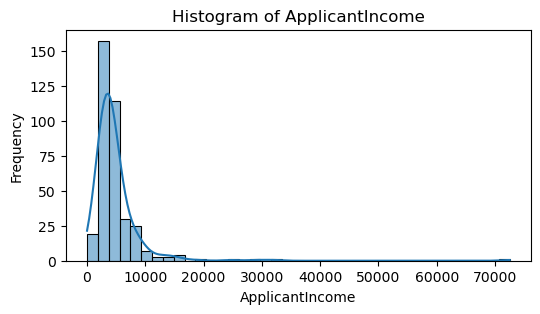

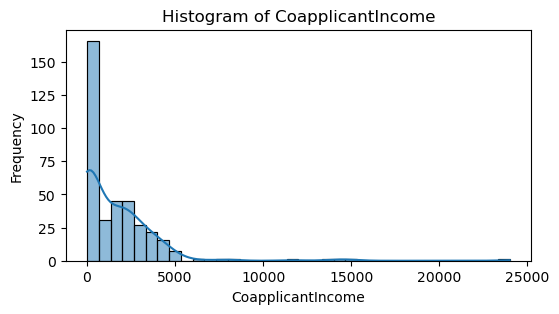

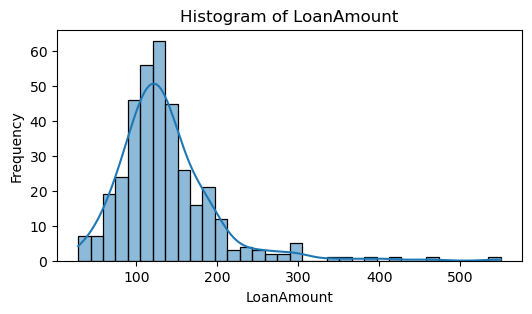

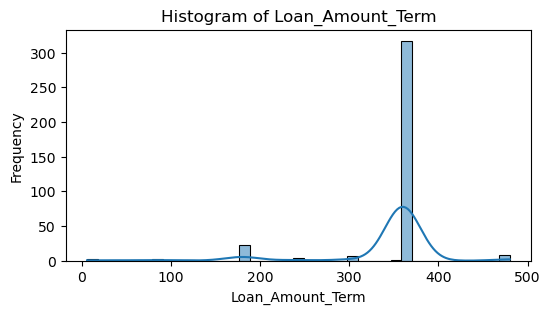

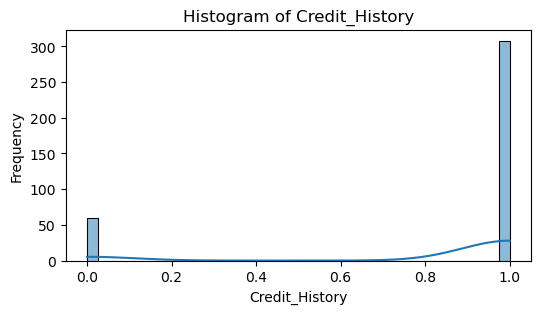

In [42]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

##### Box Plots: Identify potential outliers and visualize the spread of data.


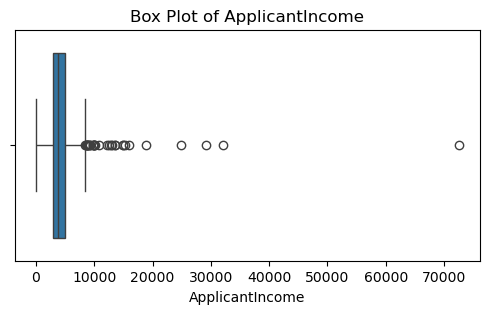

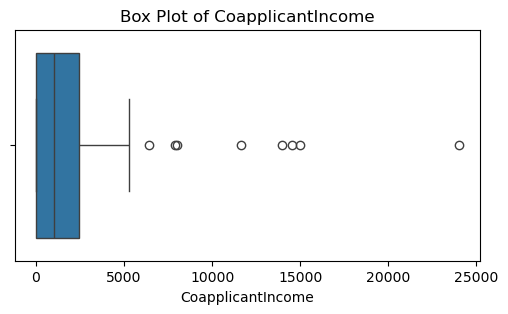

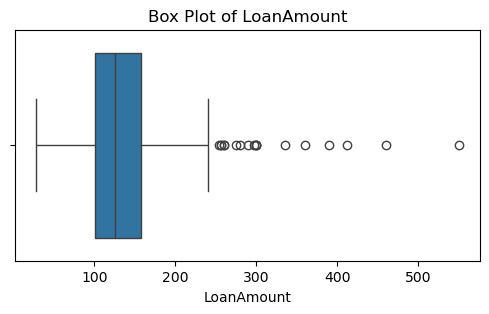

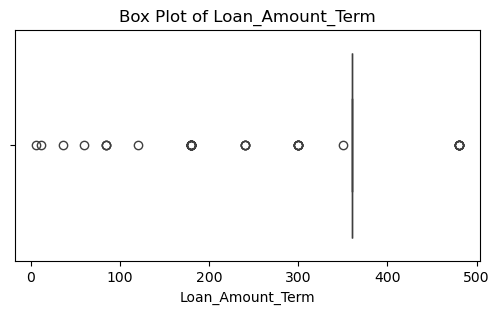

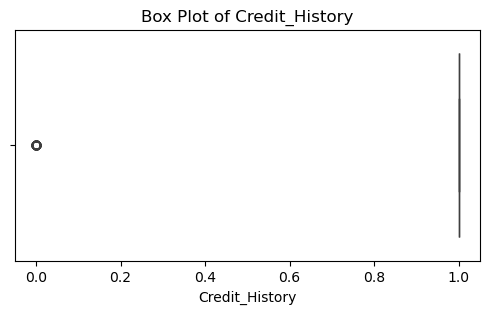

In [48]:
num_cols2 = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols2:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

##### Analyze categorical variables by creating the following plots:

In [50]:
df.select_dtypes(include="object").columns #to identify the categorical column/data

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area'],
      dtype='object')

##### Bar Charts: Visualize the frequency distribution of categorical variables.

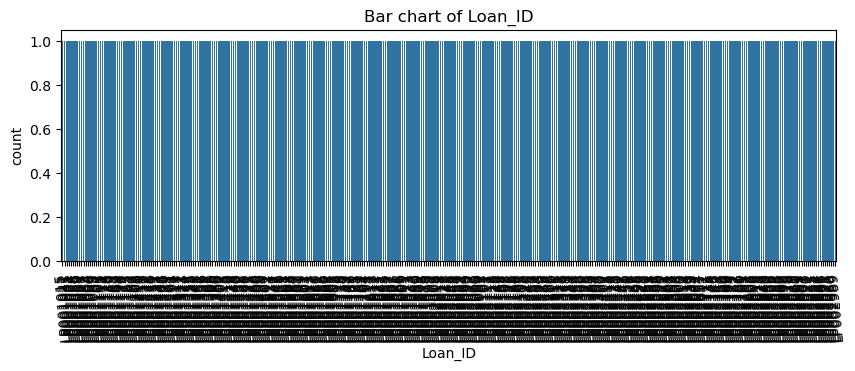

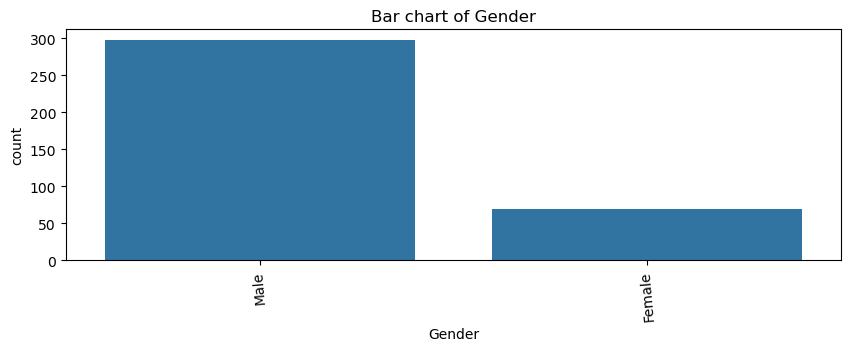

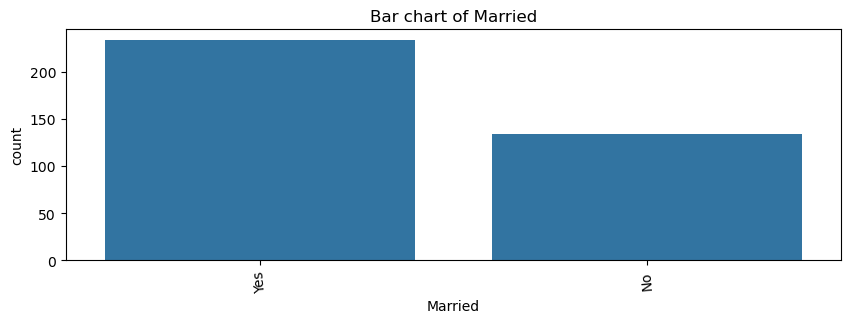

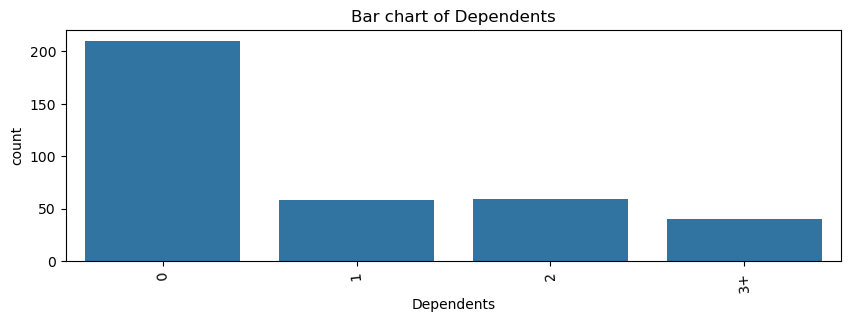

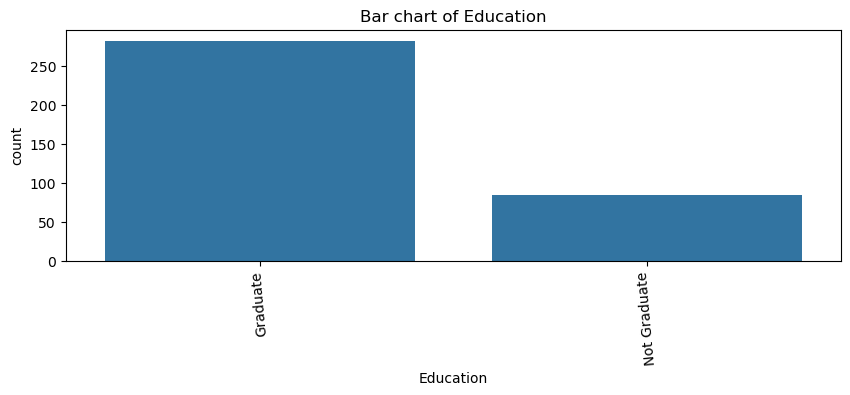

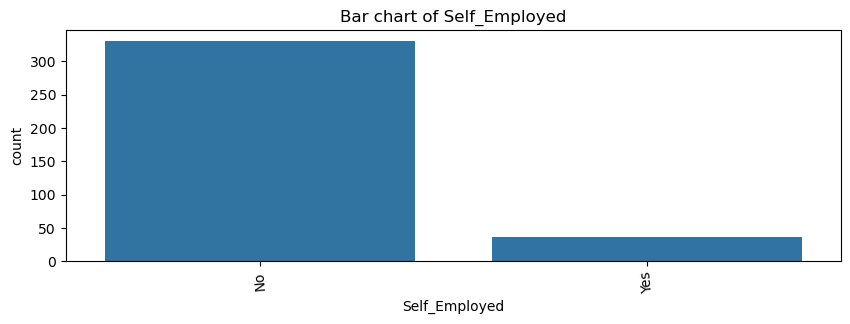

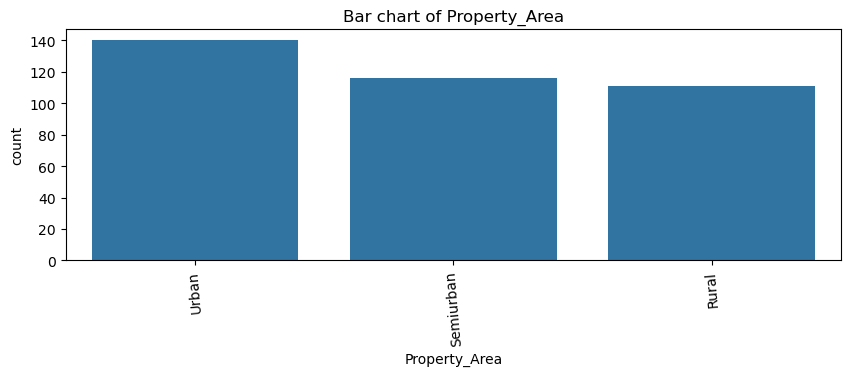

In [56]:
# countplot() automatically counts category occurrences and displays them as bars.
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(10,3))
    sns.countplot(x=col, data=df)
    plt.title(f'Bar chart of {col}')
    plt.xticks(rotation=95)
    plt.show()

##### Pie Charts: Represent the composition of categorical variables.

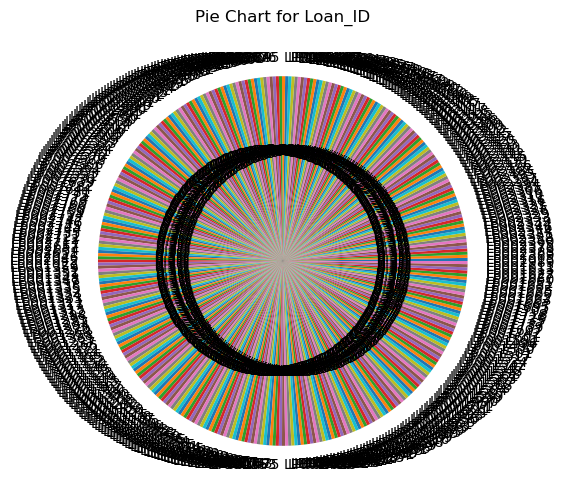

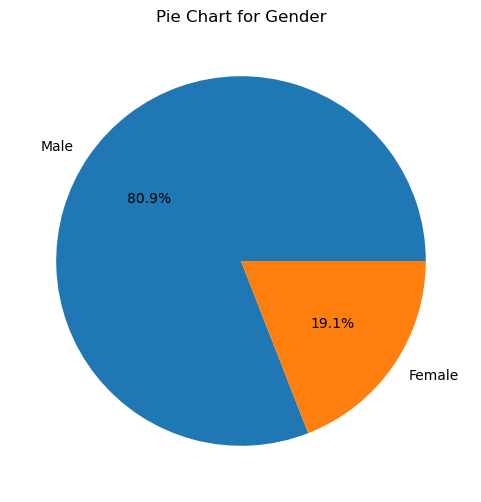

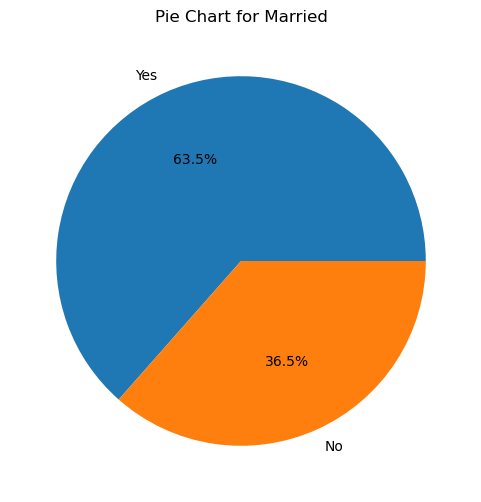

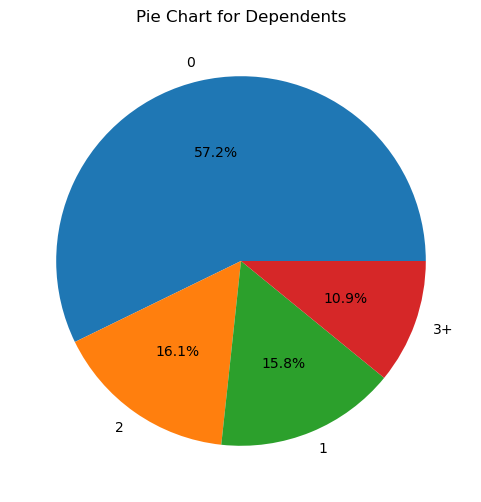

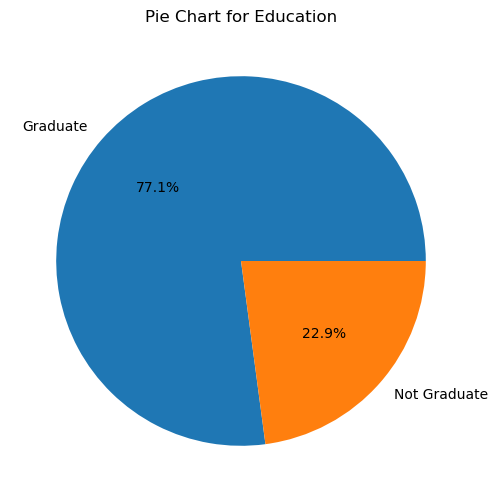

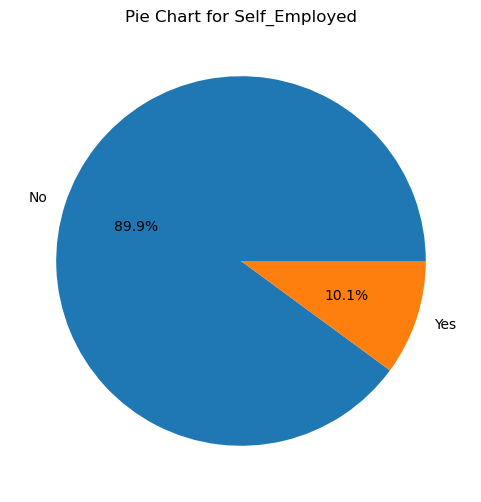

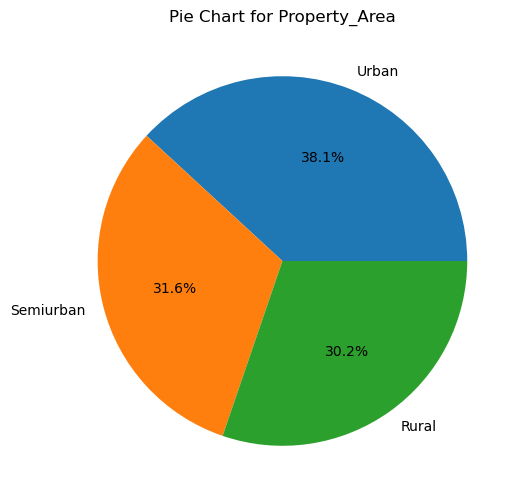

In [59]:
cat_val_pie=df.select_dtypes(include='object').columns

for pie in cat_val_pie:
    plt.figure(figsize=(6,6))
    df[pie].value_counts().plot(kind = 'pie', autopct='%1.1f%%')
    plt.title(f'Pie Chart for {pie}')
    plt.ylabel('')
    plt.show

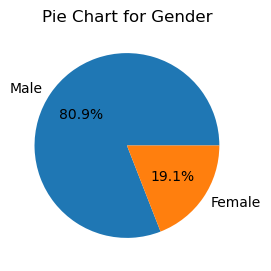

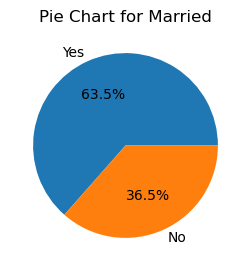

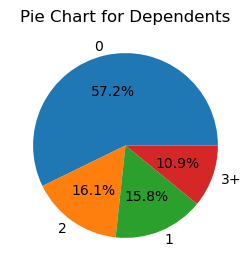

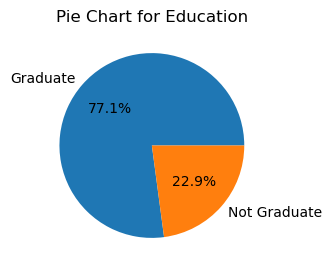

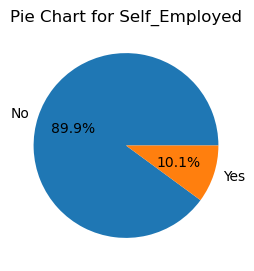

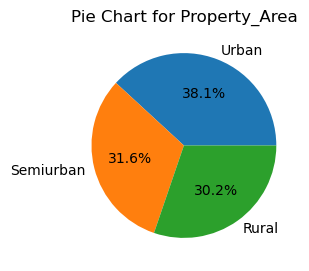

In [63]:
#Droping Loan Id due to large data, becomes unreadable with 367 slices
cat_val_pie=df.select_dtypes(include='object').columns.drop('Loan_ID') 

for pie in cat_val_pie:
    plt.figure(figsize=(6,3))
    df[pie].value_counts().plot(kind = 'pie', autopct='%1.1f%%')
    plt.title(f'Pie Chart for {pie}')
    plt.ylabel('')
    plt.show

##### 2.2 Bivariate Analysis

##### Create scatter plots to explore relationships between pairs of numeric variables.

##### A. Scatter plot between Applicant Income VS loan Amount

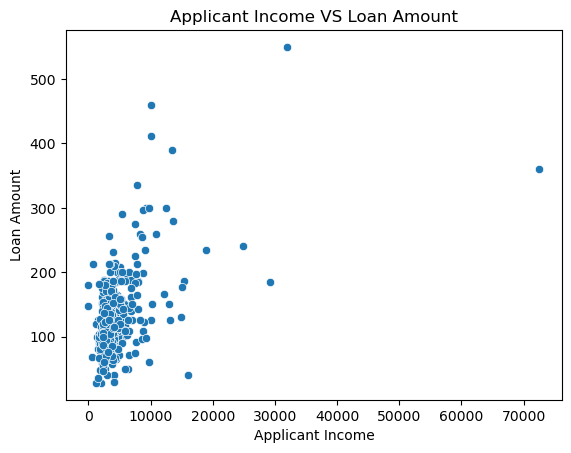

In [64]:
sns.scatterplot(x='ApplicantIncome',y='LoanAmount', data=df)
plt.title('Applicant Income VS Loan Amount')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.show()

The scatter plot between Applicant Income and Loan Amount shows a weak positive relationship. 
Most applicants have incomes below 10,000 and loan amounts below 200. A few extreme values indicate the presence of outliers.

##### B. Scatter plot between Co-Applicant Income VS Loan Amount

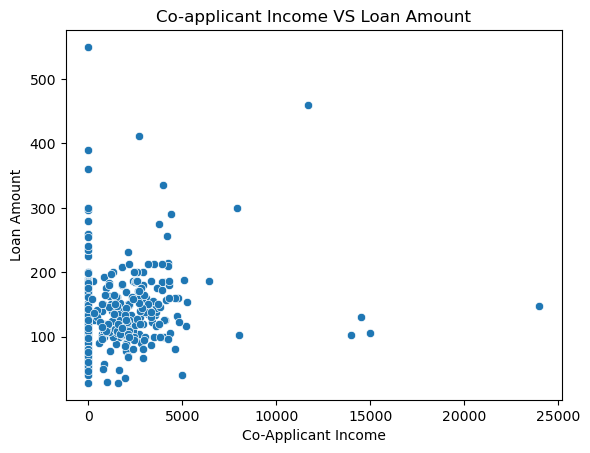

In [66]:
sns.scatterplot(x='CoapplicantIncome',y='LoanAmount', data =df)
plt.title("Co-applicant Income VS Loan Amount")
plt.xlabel("Co-Applicant Income")
plt.ylabel("Loan Amount")
plt.show()

A scatter plot was created to examine the relationship between Co-Applicant Income and Loan Amount. The plot helps visualize the distribution of data and identify trends and outliers.
A weak positive relationship is observed, with a few extreme values present.

##### C. Scatterplot between Loan Amount Term VS Loan Amount

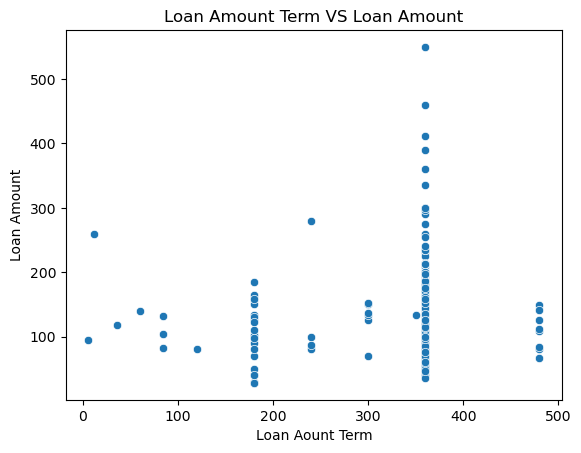

In [68]:
sns.scatterplot(x='Loan_Amount_Term', y='LoanAmount', data=df)
plt.title("Loan Amount Term VS Loan Amount")
plt.xlabel("Loan Aount Term")
plt.ylabel("Loan Amount")
plt.show()

A scatter plot was created to examine the relationship between loan amount term and loan amount.
The plot helps visualize the distribution of loan amounts across different loan terms and identify any trends or outliers.

##### Use pair plots (scatter matrix) to visualize interactions between multiple numeric variables simultaneously.

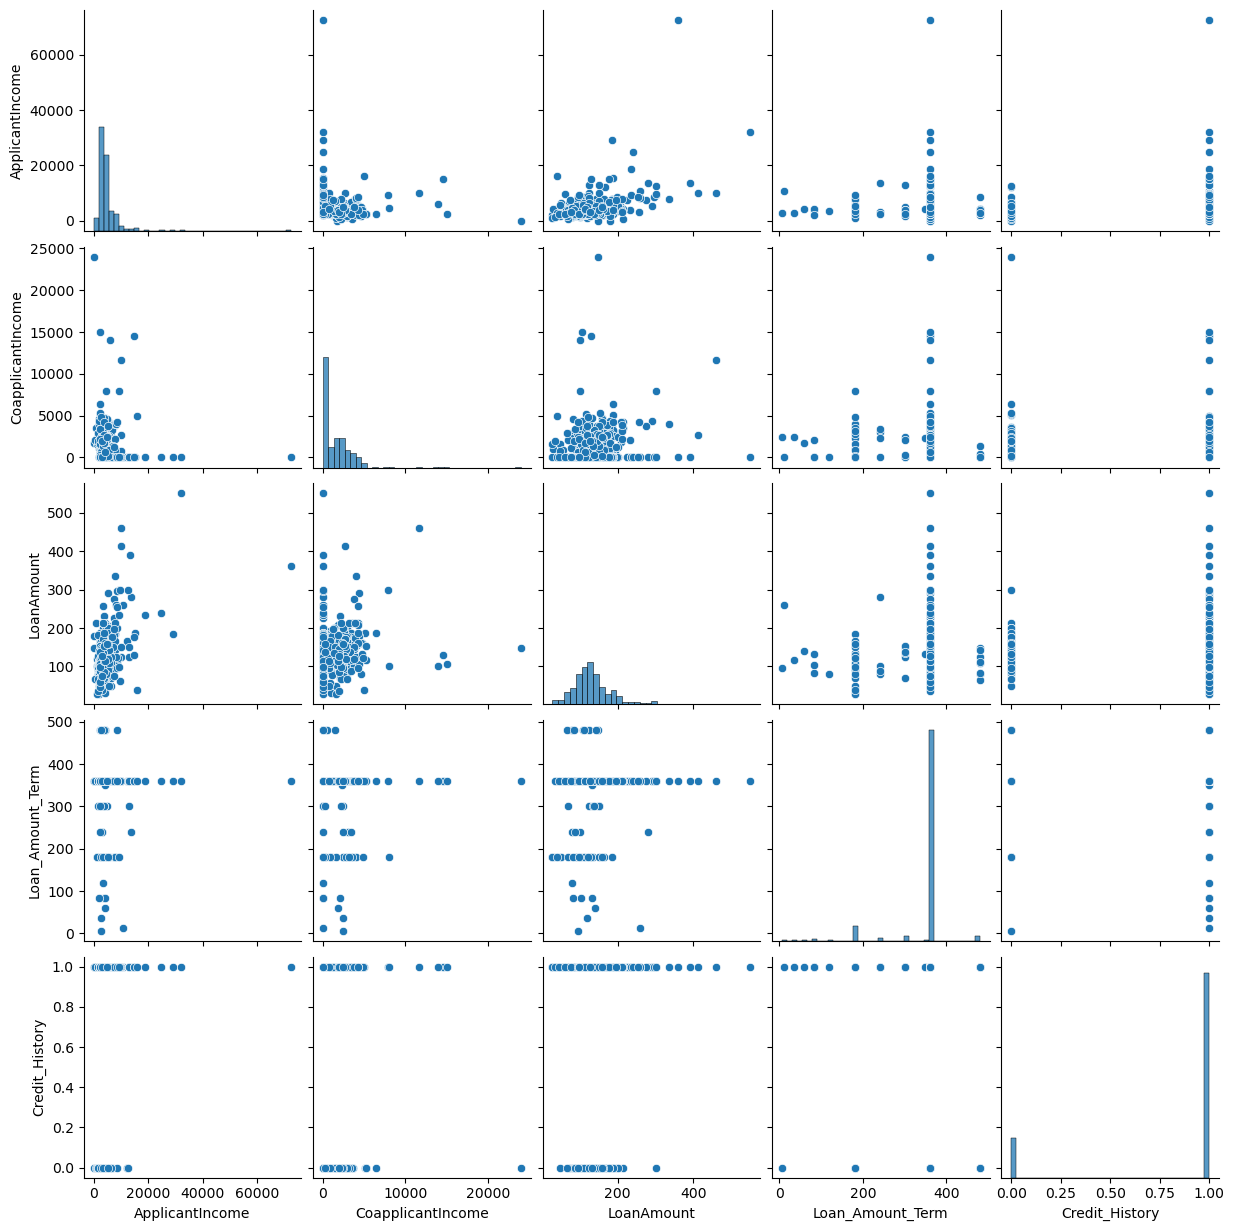

In [69]:
num_var_col = df.select_dtypes(include=['int64','float64']).columns
sns.pairplot(df[num_var_col])
plt.show()

##### Investigate the relationship categorical and numeric variables using box plots or violin plots.

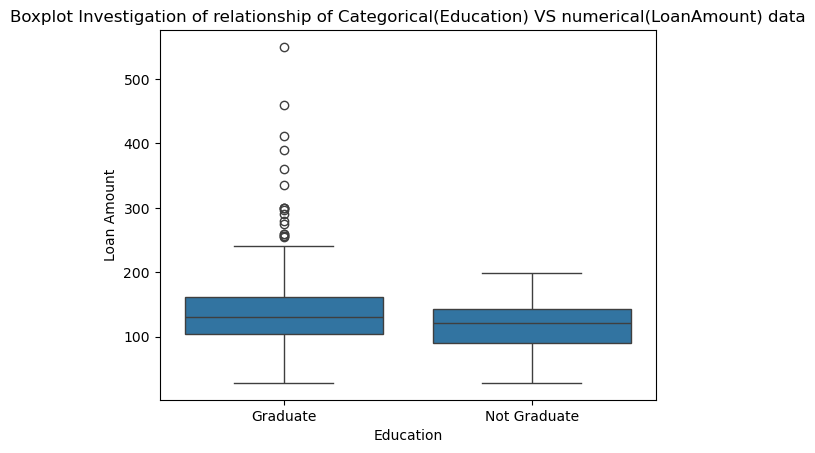

In [71]:
# Boxplot Investigation of relationship of Categorical(Education) VS numerical(LoanAmount) data
sns.boxplot(x='Education', y='LoanAmount', data=df)
plt.title('Boxplot Investigation of relationship of Categorical(Education) VS numerical(LoanAmount) data')
plt.xlabel('Education')
plt.ylabel('Loan Amount')
plt.show()

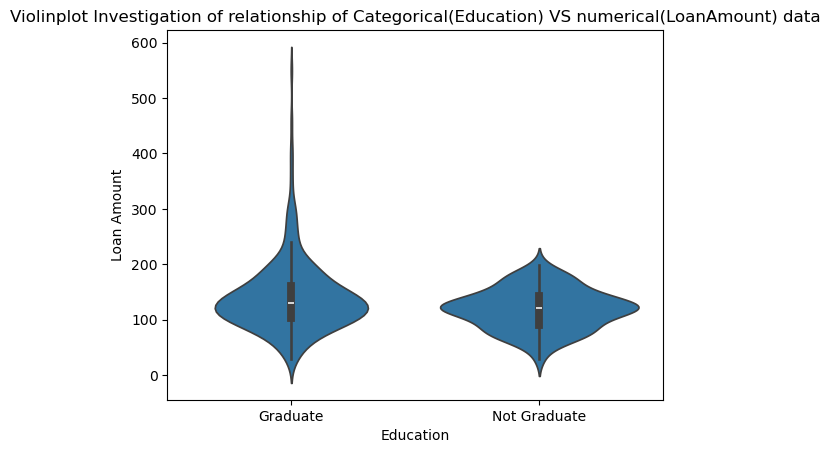

In [72]:
# Violinplot Investigation of relationship of Categorical(Education) VS numerical(LoanAmount) data
sns.violinplot(x='Education',y='LoanAmount',data=df)
plt.title("Violinplot Investigation of relationship of Categorical(Education) VS numerical(LoanAmount) data")
plt.xlabel("Education")
plt.ylabel("Loan Amount")
plt.show()

2.3 Multivariate Analysis

##### Perform a correlation analysis to identify relationships between numeric variables.

In [73]:
num_var = df.select_dtypes(include=['int64','float64']).columns
correlation = df[num_var].corr()
correlation

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.110335,0.488737,0.023319,0.094944
CoapplicantIncome,-0.110335,1.000000,0.150034,-0.008633,-0.058004
LoanAmount,0.488737,0.150034,1.000000,0.091867,-0.012932
Loan_Amount_Term,0.023319,-0.008633,0.091867,1.000000,-0.048189
Credit_History,0.094944,-0.058004,-0.012932,-0.048189,1.000000


Correlation analysis shows a moderate positive relationship between applicant income and loan amount (0.49), suggesting that higher incomes tend to be associated with larger loan amounts. Most other variables exhibit weak correlations, indicating little linear relationship between them.

##### Visualize correlations using a heatmap.

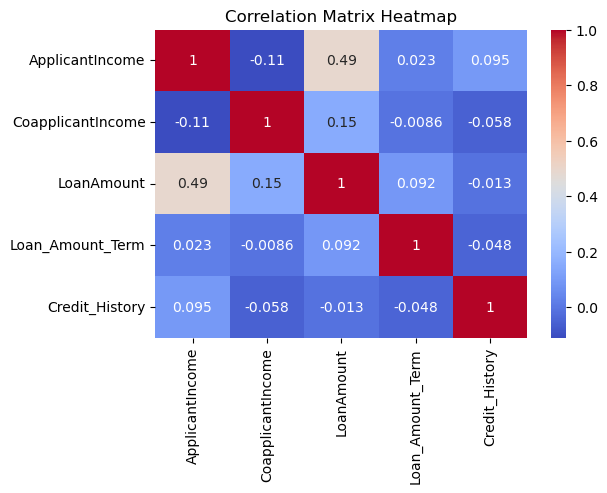

In [79]:
plt.figure(figsize=(6,4))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

##### Create a stacked bar chart to show the distribution of categorical variables across multiple categories.

In [80]:
stacked_chart = pd.crosstab(df['Education'], df['Property_Area'])
stacked_chart

Property_Area,Rural,Semiurban,Urban
Education,,,
Graduate,85,87,111
Not Graduate,26,29,29


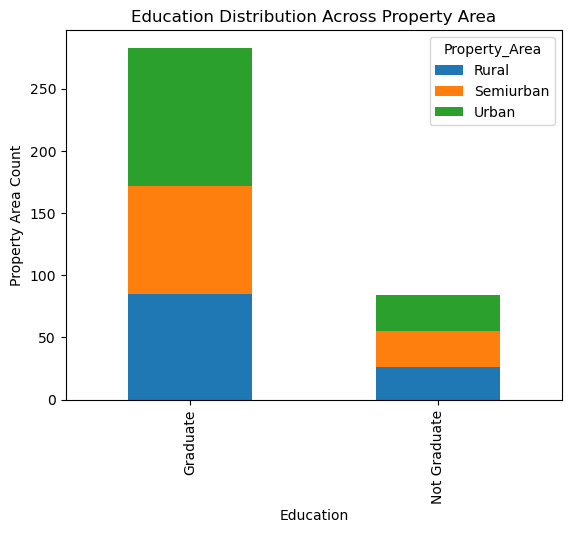

In [88]:
stacked_chart.plot(kind='bar', stacked= True)
plt.title("Education Distribution Across Property Area")
plt.xlabel("Education")
plt.ylabel("Property Area Count")
plt.show()

### Task 3:Geospatial Analysis(Optional)

##### If the dataset contains geographical information, visualize data on a map to identify regional trends.

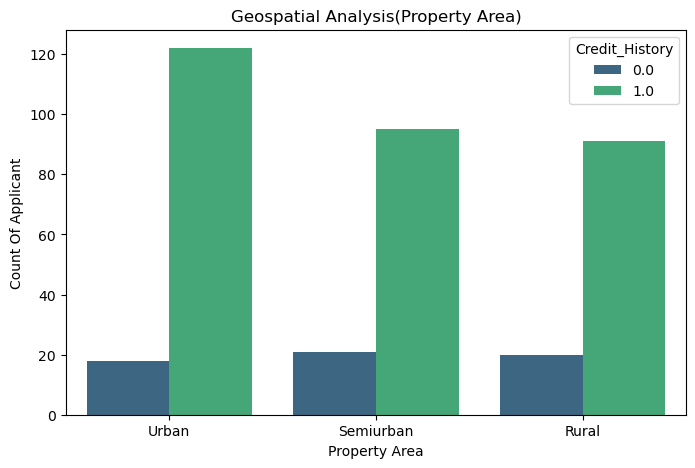

In [92]:
# Use scatter plots or heatmaps to display data patterns across geographic locations.

plt.figure(figsize=(8,5))
sns.countplot(x='Property_Area', hue='Credit_History', data=df, palette="viridis")
plt.title('Geospatial Analysis(Property Area)')
plt.xlabel('Property Area')
plt.ylabel('Count Of Applicant')
plt.show()

##### Use scatter plots or heatmaps to display data patterns across geographic locations.


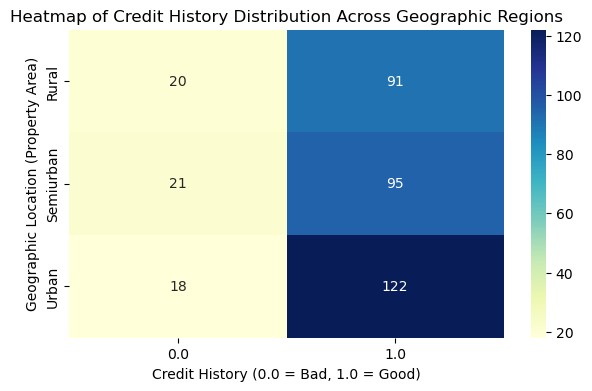

In [93]:
# Create a cross-tabulation of Property Area and Credit History
region_matrix = pd.crosstab(df['Property_Area'], df['Credit_History'])

# Plotting the categorical heatmap for regional patterns
plt.figure(figsize=(7, 4))
sns.heatmap(region_matrix, annot=True, cmap='YlGnBu', fmt='d', cbar=True)
plt.title('Heatmap of Credit History Distribution Across Geographic Regions')
plt.xlabel('Credit History (0.0 = Bad, 1.0 = Good)')
plt.ylabel('Geographic Location (Property Area)')
plt.show()

### Geospatial analysis was not performed well because the dataset lacks geographical coordinates or location-specific information required for map-based visualizations.